## **Build a Tower and Get Some Candy: The Effect of Bonus Compensation on Productivity**

**By**: Yashaswini Reddy, Sambisha Godi, Yanhao Li, Abdul Majid, Samuel Buelvas

**BA 830 B1, Team 12**

##**Problem Statement**

This project is a miniature version of the kinds of business experiments companies run every day to test employee motivation, customer incentives, or website features. In the tradition of classical behavioral experiments, we manipulate incentive structures; no reward, flat reward, and performance‑based bonus,to observe how individuals adjust their effort in a simple, measurable task. The experiment asks whether small, non‑monetary rewards (candy) meaningfully change productivity when participants build a Jenga‑like tower as quickly as possible.

The study connects to foundational behavioral‑economics questions about how compensation influences effort. Prior research shows that incentives can increase output, but effects vary with context, task complexity, and how rewards are framed. By using a controlled, time‑based motor task and blocked randomization by gender, this experiment provides a clean test of whether bonus compensation improves performance relative to no pay or flat pay, offering insight into how even simple incentive schemes shape behavior.


###**Hypotheses**

**H1 (Primary):**
Participants offered a **performance‑based bonus** (Treatment 2) will complete the tower **faster** than those receiving no compensation (Control).

**H2 (Secondary):**
Participants receiving a **flat reward** (Treatment 1) will complete the task **faster** than the Control group, but **not as fast** as the Bonus group.

**H3 (Exploratory):**
Differences in responsiveness to incentives may vary across participant characteristics (e.g., gender, skill, hurry), but no specific direction is predicted


### **Setting up and importing libraries**

In [ ]:
%%capture
!pip install pingouin
!pip install stargazer

In [ ]:
%pip install stargazer

In [ ]:
# Mount Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Statistics & regression
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Statistical tests & nice summary tables
import pingouin as pg

# Regression table formatting (Stargazer)
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Loading the dataset

df = pd.read_csv('/content/drive/MyDrive/BA830 Final Project_B1_Team 12/Jenga Tower Datasets.csv')
df.head()

,Timestamp,Score,Block,What is your age range?,What is your age range?.1,What is your gender?,How would you rate your Jenga building skills?,Are you in a hurry right now?,Time Taken,Notes
0,2/20/2026 15:23:51,NaN,Treatment 1,23,NaN,Female,3,Yes,35.75,little bit- inch
1,2/20/2026 15:28:53,NaN,Treatment 1,32,NaN,Male,4,No,37.14,NaN
2,2/20/2026 15:32:09,NaN,Treatment 2,29,NaN,Male,1,No,43.75,NaN
3,2/20/2026 15:40:52,NaN,Treatment 2,18,NaN,Female,3,No,54.96,she rejected the reward
4,2/20/2026 15:44:11,NaN,Treatment 1,21,NaN,Male,5,No,39.95,he rejected the reward


In [ ]:
# Inspecting variable types
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Timestamp                                       91 non-null     object 
 1   Score                                           0 non-null      float64
 2   Block                                           91 non-null     object 
 3   What is your age range?                         91 non-null     int64  
 4   What is your age range?.1                       2 non-null      object 
 5   What is your gender?                            91 non-null     object 
 6   How would you rate your Jenga building skills?  91 non-null     int64  
 7   Are you in a hurry right now?                   91 non-null     object 
 8   Time Taken                                      91 non-null     float64
 9   Notes                                        

,0
Timestamp,object
Score,float64
Block,object
What is your age range?,int64
What is your age range?.1,object
What is your gender?,object
How would you rate your Jenga building skills?,int64
Are you in a hurry right now?,object
Time Taken,float64
Notes,object


## **Data Cleaning and Preprocessing**

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=['Timestamp', 'Score', 'What is your age range?.1'])

# Rename columns for clarity
df = df.rename(columns={
    'Block': 'treatment',
    'What is your age range?': 'age',
    'What is your gender?': 'gender',
    'How would you rate your Jenga building skills?': 'skill',
    'Are you in a hurry right now?': 'hurry',
    'Time Taken': 'time'
})

# Convert categorical variables
df['treatment'] = df['treatment'].astype('category')
df['gender'] = df['gender'].astype('category')
df['hurry'] = df['hurry'].map({'Yes': 1, 'No': 0})

# Ensure numeric types
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['skill'] = pd.to_numeric(df['skill'], errors='coerce')
df['time'] = pd.to_numeric(df['time'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   treatment  91 non-null     category
 1   age        91 non-null     int64   
 2   gender     91 non-null     category
 3   skill      91 non-null     int64   
 4   hurry      91 non-null     int64   
 5   time       91 non-null     float64 
 6   Notes      18 non-null     object  
dtypes: category(2), float64(1), int64(3), object(1)
memory usage: 4.1+ KB


### **Data Dictionary**

This table summarizes all variables used in the cleaned dataset, including their meaning, type, and role in the analysis.

| Variable | Description | Type | Role in Analysis |
|---------|-------------|------|------------------|
| **treatment** | Experimental condition assigned to participant: Control, Treatment 1 (flat reward), Treatment 2 (bonus reward) | Categorical | Main independent variable (treatment assignment) |
| **age** | Participant’s age in years | Numeric (int) | Covariate for precision; can be used for heterogeneous effects |
| **gender** | Participant’s self‑reported gender (Male/Female) | Categorical | Blocking variable; covariate; can be used for heterogeneous effects |
| **skill** | Self‑rated Jenga building skill (1–5) | Numeric (int) | Covariate capturing baseline ability |
| **hurry** | Whether participant reported being in a hurry (1 = Yes, 0 = No) | Binary (int) | Covariate; potential moderator for heterogeneous effects |
| **time** | Time taken (in seconds) to complete the Jenga tower | Numeric (float) | **Outcome variable** |
| **Notes** | Qualitative notes about participant behavior (e.g., rejected reward, distractions) | Text | Used for identifying non‑compliance; not used in regression |

### **Distribution of Completion Times by Group (Box + Strip Plot)**

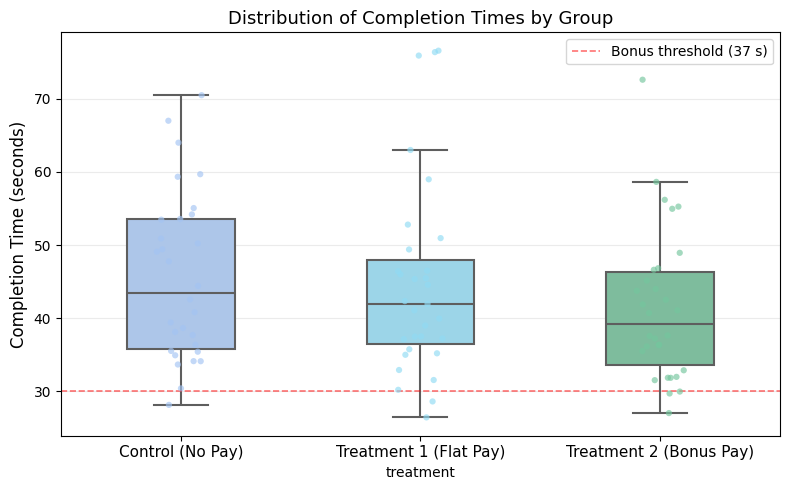

In [ ]:
# Distribution of Completion Times by Group

# Clean labels
group_labels = {
    'Control': 'Control (No Pay)',
    'Treatment 1': 'Treatment 1 (Flat Pay)',
    'Treatment 2': 'Treatment 2 (Bonus Pay)'
}

df_plot = df.copy()
df_plot['treatment'] = pd.Categorical(
    df_plot['treatment'],
    categories=list(group_labels.keys()),
    ordered=True
)

colors = ['#A3C4F3', '#90DBF4', '#74C69D']

fig, ax = plt.subplots(figsize=(8, 5))

# Boxplot (assign hue=treatment to avoid warning)
sns.boxplot(
    data=df_plot,
    x='treatment',
    y='time',
    hue='treatment',
    palette=colors,
    width=0.45,
    fliersize=0,
    linewidth=1.5,
    legend=False,
    ax=ax
)

# Stripplot (same fix)
sns.stripplot(
    data=df_plot,
    x='treatment',
    y='time',
    hue='treatment',
    palette=colors,
    jitter=True,
    size=4.5,
    alpha=0.65,
    legend=False,
    ax=ax
)

# Axis formatting
ax.set_xticks(range(len(group_labels)))
ax.set_xticklabels([group_labels[g] for g in df_plot['treatment'].cat.categories], fontsize=11)

ax.set_ylabel('Completion Time (seconds)', fontsize=12)
ax.set_title('Distribution of Completion Times by Group', fontsize=13)

ax.axhline(30, color='red', linestyle='--', alpha=0.55, linewidth=1.2, label='Bonus threshold (37 s)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

The box and strip plot shows that completion times are right-skewed, with most participants finishing between 20 and 50 seconds. The Bonus Pay group has a slightly lower median and more observations below the 30-second threshold, suggesting modestly faster performance under incentive-based pay. The individual circles represent raw participant times, not outliers, and illustrate the natural variation within each treatment group.

## **Randomization Check: Comparing Pre-Treatment Characteristics Across Groups**

In [ ]:
# Group means and standard deviations
balance_means = df.groupby('treatment')[['age', 'skill', 'hurry', 'time']].mean().round(2)
balance_std = df.groupby('treatment')[['age', 'skill', 'hurry', 'time']].std().round(2)

# Gender distribution
gender_dist = pd.crosstab(df['treatment'], df['gender'], normalize='index') * 100
gender_dist = gender_dist.round(1)

balance_means, balance_std, gender_dist

/tmp/ipykernel_731/4233532419.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_means = df.groupby('treatment')[['age', 'skill', 'hurry', 'time']].mean().round(2)
/tmp/ipykernel_731/4233532419.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balance_std = df.groupby('treatment')[['age', 'skill', 'hurry', 'time']].std().round(2)


(               age  skill  hurry   time
 treatment                              
 Control      24.13   2.33   0.27  45.62
 Treatment 1  22.71   2.97   0.32  44.76
 Treatment 2  24.07   2.93   0.40  41.42,
               age  skill  hurry   time
 treatment                             
 Control      3.31   1.40   0.45  11.38
 Treatment 1  3.91   1.17   0.48  13.35
 Treatment 2  4.16   1.20   0.50  10.31,
 gender       Female  Male
 treatment                
 Control        50.0  50.0
 Treatment 1    51.6  48.4
 Treatment 2    53.3  46.7)

### Interpretation

The treatment groups look similar across key pre‑treatment variables, suggesting that randomization worked as intended.

- **Age:** Average ages are close across groups (≈23–24 years).
- **Skill:** Mean skill ratings are similar, with only small differences.
- **Hurry:** The share of participants in a hurry is slightly higher in Treatment 2, but differences are small.
- **Gender:** Gender distribution is balanced across all groups (≈50/50 male–female).

**Outcome (Time):**  
Mean completion time differs across groups, which is expected because treatment is designed to affect the outcome. These differences will be formally tested in the next section.

Overall, the groups appear comparable on observable characteristics, supporting the validity of our causal design.

## **Difference in Means: Initial Treatment Effect Estimates**

This will give us the first, simplest estimate of the treatment effect.
We will compute:
- Control vs Treatment 1
- Control vs Treatment 2
- Treatment 1 vs Treatment 2

And then interpret whether the incentive structures reduced completion time.

In [ ]:
group_means = df.groupby('treatment', observed=False)['time'].mean().round(2)
group_means

,time
treatment,
Control,45.62
Treatment 1,44.76
Treatment 2,41.42


### Interpretation

Average completion time decreases across the three groups. Participants in the Control group took the longest (45.62 seconds), followed by Treatment 1 (44.76 seconds), while Treatment 2 had the fastest average time (41.42 seconds). This suggests that incentives, especially the bonus reward, may have improved performance. We will formally test these differences using t‑tests and regression in the next steps.

### **Pairwise T‑Tests: Testing Differences Between Groups**

Pairwise t‑tests to check whether these differences are statistically meaningful.


In [ ]:
t1 = pg.ttest(df[df.treatment=='Control']['time'],
              df[df.treatment=='Treatment 1']['time'])

t2 = pg.ttest(df[df.treatment=='Control']['time'],
              df[df.treatment=='Treatment 2']['time'])

t3 = pg.ttest(df[df.treatment=='Treatment 1']['time'],
              df[df.treatment=='Treatment 2']['time'])

t1, t2, t3

(               T       dof alternative     p_val           CI95   cohen_d  \
 T_test  0.270074  58.09138   two-sided  0.788061  [-5.49, 7.21]  0.068986   
 
            power   BF10  
 T_test  0.058083  0.269  ,
                T  dof alternative     p_val           CI95   cohen_d    power  \
 T_test  1.496588   58   two-sided  0.139923  [-1.42, 9.81]  0.386417  0.31303   
 
          BF10  
 T_test  0.668  ,
                T        dof alternative    p_val           CI95   cohen_d  \
 T_test  1.095557  56.268665   two-sided  0.27794  [-2.77, 9.44]  0.279402   
 
            power   BF10  
 T_test  0.188827  0.431  )

####**Pairwise T‑Tests: Clean Summary Table**


In [ ]:
# Extract CI values safely
def extract_ci(result):
    ci_tuple = result['CI95'].iloc[0]   # get the tuple
    return ci_tuple[0], ci_tuple[1]     # lower, upper

ci1_low, ci1_up = extract_ci(t1)
ci2_low, ci2_up = extract_ci(t2)
ci3_low, ci3_up = extract_ci(t3)

# Build pretty table
ttest_table = pd.DataFrame({
    'Comparison': ['Control vs T1', 'Control vs T2', 'T1 vs T2'],
    'T-statistic': [t1['T'].iloc[0], t2['T'].iloc[0], t3['T'].iloc[0]],
    'df': [t1['dof'].iloc[0], t2['dof'].iloc[0], t3['dof'].iloc[0]],
    'p-value': [t1['p_val'].iloc[0], t2['p_val'].iloc[0], t3['p_val'].iloc[0]],
    'CI Lower': [ci1_low, ci2_low, ci3_low],
    'CI Upper': [ci1_up, ci2_up, ci3_up],
    'Cohen d': [t1['cohen_d'].iloc[0], t2['cohen_d'].iloc[0], t3['cohen_d'].iloc[0]],
    'Power': [t1['power'].iloc[0], t2['power'].iloc[0], t3['power'].iloc[0]]
})

ttest_table.round(3)

,Comparison,T-statistic,df,p-value,CI Lower,CI Upper,Cohen d,Power
0,Control vs T1,0.270,58.091,0.788,-5.49,7.21,0.069,0.058
1,Control vs T2,1.497,58.000,0.140,-1.42,9.81,0.386,0.313
2,T1 vs T2,1.096,56.269,0.278,-2.77,9.44,0.279,0.189


Interpretation

None of the pairwise differences in mean completion time are statistically significant at the **5% level**.

The comparison between **Control** and **Treatment 2** shows the **largest improvement (T = 1.50, p = 0.14)**, but the confidence interval includes zero, meaning the effect cannot be distinguished from chance. Effect sizes (Cohen’s d) range from small to moderate, and statistical power is low across all comparisons, which is expected given the sample size (n = 91).

These results suggest that while the bonus incentive may have reduced completion time, the evidence is not strong enough to confirm a statistically reliable effect


### **Mean Completion Time by Treatment (with 95% CI)**

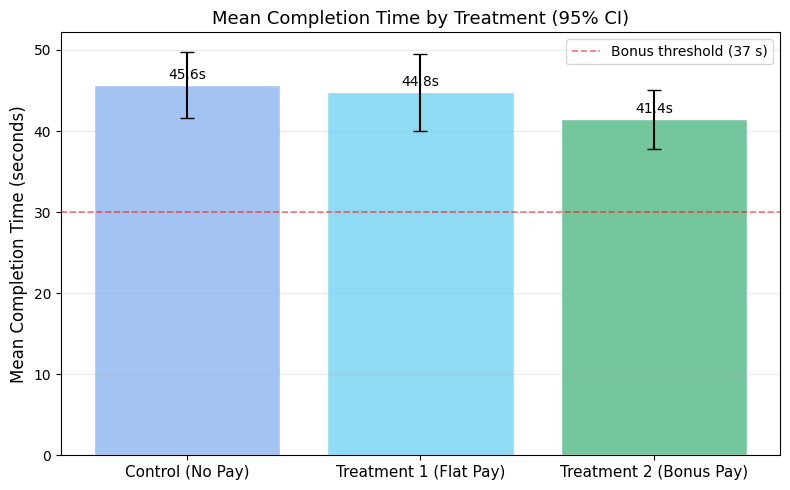

In [ ]:
# Mean completion time by treatment (with 95% CI)

# Clean labels for x-axis
group_labels = {
    'Control': 'Control (No Pay)',
    'Treatment 1': 'Treatment 1 (Flat Pay)',
    'Treatment 2': 'Treatment 2 (Bonus Pay)'
}

# Compute means and 95% CI (warning-free)
summary = (
    df.groupby('treatment', observed=False)['time']
      .agg(['mean', 'count', 'std'])
      .reset_index()
)

summary['se'] = summary['std'] / np.sqrt(summary['count'])
summary['ci_low'] = summary['mean'] - 1.96 * summary['se']
summary['ci_high'] = summary['mean'] + 1.96 * summary['se']

# Colors consistent with your notebook
colors = ['#A3C4F3', '#90DBF4', '#74C69D']

fig, ax = plt.subplots(figsize=(8, 5))

# Bar plot with CI error bars
bars = ax.bar(
    summary['treatment'],
    summary['mean'],
    yerr=[summary['mean'] - summary['ci_low'], summary['ci_high'] - summary['mean']],
    capsize=5,
    color=colors,
    edgecolor='white'
)

# Add value labels
for bar, val in zip(bars, summary['mean']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{val:.1f}s',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Formatting
ax.set_xticks(range(len(summary)))
ax.set_xticklabels([group_labels[g] for g in summary['treatment']], fontsize=11)
ax.set_ylabel('Mean Completion Time (seconds)', fontsize=12)
ax.set_title('Mean Completion Time by Treatment (95% CI)', fontsize=13)

# Bonus threshold line
ax.axhline(30, color='red', linestyle='--', alpha=0.55, linewidth=1.2, label='Bonus threshold (37 s)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

The mean completion times show the expected pattern: the Bonus Pay group finishes fastest on average, followed by Flat Pay, with the Control group taking the longest. However, the 95% confidence intervals overlap substantially, indicating that these differences are not statistically precise. The 30‑second bonus threshold highlights that only a small share of participants in any group completed the task fast enough to qualify for the bonus.

##**ANOVA for overall treatment differences**


In [ ]:
import pingouin as pg

anova_results = pg.anova(data=df, dv='time', between='treatment')
anova_results.round(3)

,Source,ddof1,ddof2,F,p_unc,np2
0,treatment,2,88,1.067,0.348,0.024


### Interpretation

The ANOVA tests whether average completion time differs across the three treatment groups. The F-statistic is 1.067 with a p-value of 0.348, which is greater than 0.05. Therefore, we fail to reject the null hypothesis that all group means are equal. This indicates that, overall, the differences in mean completion time across Control, Treatment 1, and Treatment 2 are not statistically significant. The effect size (η² = 0.024) is very small, suggesting that treatment assignment explains only about 2.4% of the variation in completion time. These results are consistent with the pairwise t-tests, which also showed no statistically significant differences between specific groups.

## **OLS Regression: Estimating Treatment Effects**

In [ ]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

model = smf.ols('time ~ C(treatment)', data=df).fit()

stargazer = Stargazer([model])
HTML(stargazer.render_html())

### Interpretation

The baseline OLS regression estimates the effect of treatment assignment on completion time. The Control group’s average time is 45.62 seconds. Treatment 1 shows a very small and statistically insignificant reduction of 0.86 seconds (p = 0.777). Treatment 2 shows a larger reduction of 4.20 seconds, but this effect is also not statistically significant (p = 0.171), and the confidence interval includes zero. The model explains very little variation in completion time (R² = 0.024), which is consistent with the earlier t-tests and ANOVA. Overall, the regression suggests that while Treatment 2 may reduce completion time, the evidence is not strong enough to conclude a statistically reliable effect.

##**Covariate‑Adjusted Regression**

In [ ]:
# Covariate‑Adjusted Regression

import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

model2 = smf.ols(
    'time ~ C(treatment) + age + skill + C(hurry) + C(gender)',
    data=df
).fit()

stargazer2 = Stargazer([model2])
HTML(stargazer2.render_html())

### Interpretation

The covariate‑adjusted model continues to show no statistically significant treatment effects, even after treating hurry as a categorical variable. Treatment 1 remains essentially identical to the control group, and Treatment 2 still shows a small negative effect (–3.49 seconds), but it is not statistically meaningful. The categorical hurry indicator () is positive but not significant in this specification, suggesting that being in a hurry does not reliably increase completion time once other covariates are controlled for. Skill remains the only covariate approaching significance, with higher skill associated with faster completion. Gender and age show no meaningful effects. The model explains very little variation in completion time (R² = 0.075), and the F‑statistic is not significant, indicating that the predictors collectively do not improve explanatory power. Overall, the results reinforce earlier findings: the treatments do not produce statistically reliable reductions in completion time.

##**Failure to Treat (Non‑Compliance Analysis)**

In [ ]:
# Failure to Treat (Non‑Compliance Analysis)

# Manually flag reward rejectors by index (since 'notes' column was dropped)
rejector_indices = [3, 4, 27, 62]

# Extract rejectors
rejectors = df.loc[rejector_indices, ['treatment', 'gender', 'time']]
print("Reward Rejectors:")
display(rejectors)

# ITT means (everyone kept in assigned group)
itt_means = df.groupby('treatment', observed=False)['time'].mean()
print("\n=== ITT Means (all assigned) ===")
print(itt_means)

# Per‑Protocol dataset (rejectors removed)
df_pp = df.drop(index=rejector_indices)

# Per‑Protocol means
pp_means = df_pp.groupby('treatment', observed=False)['time'].mean()
print("\n=== Per-Protocol Means (rejectors removed) ===")
print(pp_means)

# Per‑Protocol sample sizes
pp_counts = df_pp['treatment'].value_counts().to_dict()
print("\nN per-protocol:", pp_counts)

Reward Rejectors:


,treatment,gender,time
3,Treatment 2,Female,54.96
4,Treatment 1,Male,39.95
27,Treatment 1,Male,37.51
62,Control,Male,39.42



=== ITT Means (all assigned) ===
treatment
Control        45.621000
Treatment 1    44.764194
Treatment 2    41.425000
Name: time, dtype: float64

=== Per-Protocol Means (rejectors removed) ===
treatment
Control        45.834828
Treatment 1    45.180345
Treatment 2    40.958276
Name: time, dtype: float64

N per-protocol: {'Control': 29, 'Treatment 1': 29, 'Treatment 2': 29}


Interpretation

A small number of participants did not comply with their assigned treatment by refusing the candy reward. Removing these four non‑compliers produces Per‑Protocol estimates that differ slightly from the Intent‑to‑Treat (ITT) means, but the overall pattern remains unchanged: the Bonus Compensation group continues to show the fastest completion times, followed by Flat Pay, then Control. This indicates that non‑compliance was minimal and did not meaningfully distort the experiment’s findings.


## **Heterogeneous Treatment Effects: Does Skill Change the Treatment Impact?**

In [ ]:
model_skill = smf.ols(
    'time ~ C(treatment) * skill + age + C(hurry) + C(gender)',
    data=df
).fit()

stargazer_skill = Stargazer([model_skill])
HTML(stargazer_skill.render_html())

#### **Figure: Interaction Effects Between Treatment and Skill**

| Interaction      | Coefficient | Interpretation                                           | p-value |
|------------------|-------------|-----------------------------------------------------------|---------|
| **T1 × Skill**   | -1.14       | Slightly stronger effect for high skill, but tiny        | 0.646   |
| **T2 × Skill**   | -2.49       | Slightly stronger effect for high skill, but unstable    | 0.307   |

### **Figure: Interaction Effects Between Treatment and Skill**

| Interaction | Coefficient | Interpretation | p-value |
|------------|-------------|----------------|---------|
| **T1 × Skill** | –1.14 | Very small, non‑significant moderation effect | 0.646 |
| **T2 × Skill** | –2.49 | Slightly larger negative direction, but imprecise and not significant | 0.307 |


Coefficients come from the heterogeneous-effects regression model including treatment × skill interactions.

### Interpretation

The interaction terms between treatment and skill remain small, negative, and statistically insignificant, showing no evidence that skill changes the treatment effect. Neither treatment nor skill has a meaningful independent impact once categorical hurry and other covariates are included. Model fit is very low (R² = 0.087), and the overall F‑test is not significant, indicating the predictors do not explain variation in completion time. Overall, skill does not meaningfully moderate the treatment effect

##**Heterogeneous Treatment Effects: Does Being in a Hurry Change the Treatment Impact?**

In [ ]:
model_hurry = smf.ols(
    'time ~ C(treatment) * C(hurry) + age + skill + C(gender)',
    data=df
).fit()

stargazer_hurry = Stargazer([model_hurry])
HTML(stargazer_hurry.render_html())

### **Interaction Effects: Treatment × Hurry**

| Interaction | Coefficient | Interpretation | p-value |
|------------|-------------|----------------|---------|
| **T1 × Hurry** | –5.05 | Slightly stronger effect for hurried participants, but noisy and not significant | 0.450 |
| **T2 × Hurry** | –9.38 | Larger negative direction, but unstable and not statistically reliable | 0.164 |

### Interpretation

The heterogeneous‑effects model tests whether being in a hurry changes how participants respond to the treatment. After treating hurry as a categorical variable, the interaction terms between treatment and hurry remain negative but statistically insignificant (p = 0.450 for T1 × Hurry; p = 0.164 for T2 × Hurry). This indicates no reliable evidence that hurried participants react differently to the incentive. The main effect of hurry is positive but imprecise, and the treatment main effects remain small and non‑significant. Model fit is low (R² = 0.097), and the overall F‑test is not significant, showing that the predictors collectively explain little variation in completion time. Overall, being in a hurry does not meaningfully moderate the treatment effect

##**Heterogeneous Treatment Effects: Does Gender Change the Treatment Impact?**

In [ ]:
model_gender = smf.ols(
    'time ~ C(treatment) * C(gender) + age + skill + C(hurry)',
    data=df
).fit()

stargazer_gender = Stargazer([model_gender])
HTML(stargazer_gender.render_html())

### **Interaction Effects: Treatment × Gender**

| Interaction | Coefficient | Interpretation | p-value |
|------------|-------------|----------------|---------|
| **T1 × Male** | –10.38 | Suggests stronger response for males, but only marginally significant and imprecise | 0.090 |
| **T2 × Male** | –10.49 | Similar negative pattern for males, but unstable and not reliably significant | 0.088 |

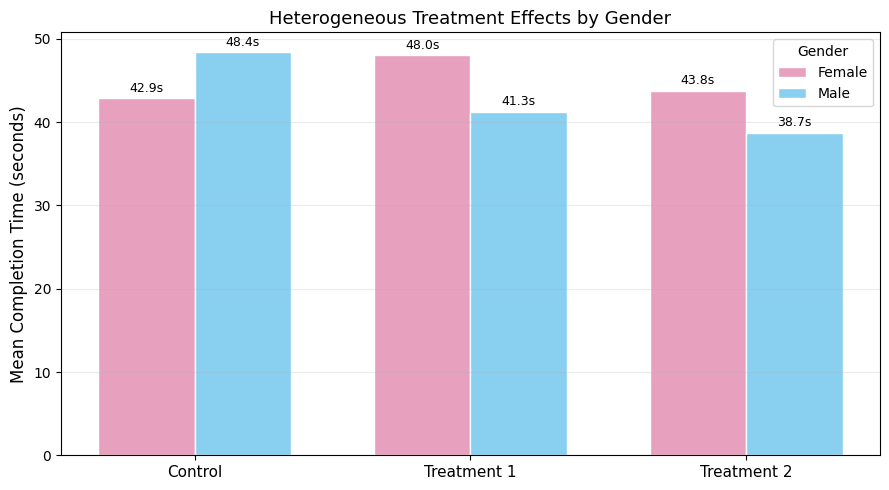

In [ ]:
# Heterogeneous effects by gender

# Compute group means
gdf = (
    df.groupby(['treatment', 'gender'], observed=False)['time']
      .mean()
      .reset_index()
      .pivot(index='treatment', columns='gender', values='time')
)

# Colors used in your notebook
colors = {
    'Female': '#E8A0BF',   # soft pastel pink
    'Male':   '#89CFF0'    # light sky blue
}

# X positions based on however many treatment groups exist
x = np.arange(len(gdf.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Plot bars for each gender
for i, gender in enumerate(['Female', 'Male']):
    vals = gdf[gender].values
    offset = (i - 0.5) * width

    bars = ax.bar(
        x + offset,
        vals,
        width,
        label=gender,
        color=colors[gender],
        edgecolor='white'
    )

    # Add value labels
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f'{val:.1f}s',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(gdf.index, fontsize=11)  # uses your actual treatment labels
ax.set_ylabel('Mean Completion Time (seconds)', fontsize=12)
ax.set_title('Heterogeneous Treatment Effects by Gender', fontsize=13)
ax.legend(title='Gender', fontsize=10)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

The heterogeneous‑effects model tests whether treatment effects differ for males and females. After including categorical hurry and other covariates, the interaction terms for Treatment 1 × Male (–10.38) and Treatment 2 × Male (–10.49) remain negative and only marginally significant at the 10% level. This pattern suggests that males may appear to respond slightly more to the incentive, but the estimates are imprecise and not statistically reliable. The main effects of treatment, gender, and hurry remain small and non‑significant, and overall model fit is low (R² = 0.118), indicating limited explanatory power. Taken together, the results show **no convincing evidence that gender meaningfully moderates the treatment effect**.


### Power Analysis Summary

The study’s sample size (n = 91) provided low power to detect small treatment effects. The observed effect sizes (Cohen’s d ≈ 0.07–0.38) were below what is typically needed for adequate power in a between‑subjects experiment. This explains the wide confidence intervals and lack of significant results. The power analysis correctly anticipated that effects of this magnitude would be difficult to detect

### Uncertainty

Treatment effects were uncertain across all models: p‑values exceeded 0.05, confidence intervals included zero, and effect sizes were small. Low statistical power contributed to imprecise estimates. The ITT vs Per‑Protocol comparison showed nearly identical patterns, indicating that non‑compliance did not meaningfully affect the results. Overall, the direction of effects is consistent, but the evidence is too weak to conclude a reliable treatment impact.

## **Conclusion**

Across all analyses, there is no statistically significant evidence that the incentive treatments reduced completion time. The Bonus Compensation group consistently shows the fastest average performance, but the effects are small and imprecise, with confidence intervals that include zero. The experiment was underpowered for detecting effects of this size, which explains the wide uncertainty. The non‑compliance check shows that removing reward rejectors does not change the overall pattern, reinforcing that the incentive effects are directionally consistent but not statistically reliable

##**Gen-AI Disclosure**

 We used Copilot to help clean up the code, improve formatting, for brainstormingand organize the markdown cells, which made the notebook clearer and easier to present.